# Rust CPU Acceleration for the MEK-Means E-step

Benchmarks the three execution backends for the MEK-Means E-step in `mminference.py`.

## E-step formula

```
logL[c,k] = Σ_g log PSS_θk_g(u_c^g, s_c^g)  +  log w_k
Q[c,k]    = softmax(logL)[c,k]
```

| Component | Backend | Precision |
|---|---|---|
| PSS grid computation | Rust (rayon) | float64 |
| Per-cell gather + log + sum + softmax | Rust (rayon) | float64 |

**Backend priority** (automatic, no flags needed):
1. CUDA GPU (float64) — requires PyTorch + a CUDA device that supports float64
2. Rust CPU — requires `monod_core` built with `maturin build --release`
3. Python fallback — sequential `eval_model_pss` loop


## Step 1 — Prerequisites

The Rust CPU fast-path requires only the `monod_core` extension:

```bash
cd monod_core
maturin build --release
pip install target/wheels/monod_core-*.whl
```

For CUDA GPU acceleration, additionally install PyTorch on a machine with a
CUDA-capable GPU that supports float64 (most server-class cards; consumer
cards often restrict float64 to 1/32 rate):

```bash
pip install torch  # or follow pytorch.org for the CUDA-enabled wheel
```


In [1]:
import sys, os, warnings, time
import numpy as np
import scipy.sparse, scipy.optimize
import matplotlib.pyplot as plt
from scipy.special import softmax

_src = os.path.join(os.path.abspath('.'), 'src', 'monod')
if _src not in sys.path:
    sys.path.insert(0, _src)

warnings.filterwarnings('ignore')

print(f"Python arch : {os.uname().machine}")
print(f"Python path : {sys.executable}")

try:
    import torch
    print(f"\nPyTorch     : {torch.__version__}")
    print(f"CUDA available : {torch.cuda.is_available()}")
except ImportError:
    print("torch not installed — install with: pip install torch")

try:
    import monod_core as _mc
    print(f"\nmonod_core  : {_mc.__file__}")
    _HAS_RUST = True
except ImportError:
    _HAS_RUST = False
    print("monod_core not found — build with: cd monod_core && maturin build --release")

import mminference as mm
print(f"\nmminference._HAS_RUST : {mm._HAS_RUST}")

if mm._HAS_RUST:
    print("\n  Rust CPU fast-path is ACTIVE")
else:
    print("\n  No fast-path — using Python fallback")


Python arch : x86_64
Python path : /Users/ConradOakes/Library/r-miniconda/envs/monod/bin/python
torch not installed — install with: pip install torch

monod_core  : /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py



mminference._HAS_RUST : True

  Rust CPU fast-path is ACTIVE


## Step 2 — Load PBMC data

In [2]:
from cme_toolbox import CMEModel
import anndata as ad
from extract_data import extract_data
from inference import searchdata_from_adata, SearchData
from mminference import GradientInference

MODEL   = CMEModel('Bursty', 'None')
N_GENES = 100
C_PY    = 'steelblue'
C_RUST  = 'firebrick'
EPS     = 1e-15

adata = ad.read_h5ad('example_h5ad/processed_pbmc_10k_raw.h5ad')
adata.var_names_make_unique()
print(f'Dataset: {adata.n_obs:,} cells  ×  {adata.n_vars:,} genes')

s_mat = adata.layers['spliced']
if scipy.sparse.issparse(s_mat):
    s_mat = s_mat.toarray()
expressed = np.where((s_mat > 0).sum(0) >= 100)[0]
GENES = [adata.var_names[i] for i in expressed[:N_GENES]]

adata_ext = extract_data(
    adata, MODEL,
    dataset_name='/tmp/pbmc_gpu_demo',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=N_GENES, genes_to_fit=GENES,
    hist_type='unique', viz=False,
)
search_data = searchdata_from_adata(adata_ext)
print(f'SearchData: {search_data.n_genes} genes, {search_data.n_cells:,} cells')

# Helper to subset SearchData to first n genes
def subset_sd(sd, n):
    attrs = ['M','hist','moments','n_genes','gene_names','n_cells','layers','hist_type','layer_names']
    vals  = [sd.M[:,:n], sd.hist[:n], sd.moments[:n], n, sd.gene_names[:n],
             sd.n_cells, sd.layers[:,:,:n], sd.hist_type, sd.layer_names]
    return SearchData(attrs, *vals)

# Helper: build GradientInference
K   = 3
lb  = np.array([-3., -3., -3.])
ub  = np.array([ 3.,  3.,  3.])
reg = np.zeros((N_GENES, 2))

def make_gi(k, epochs, n_g=N_GENES):
    g = GradientInference.__new__(GradientInference)
    g.gradient_params = {'max_iterations': 15, 'init_pattern': 'moments', 'num_restarts': 1}
    g.phys_lb = lb; g.phys_ub = ub
    g.grad_bnd = scipy.optimize.Bounds(lb, ub)
    g.n_phys_pars = MODEL.get_num_params(); g.n_samp_pars = 2
    g.inference_string = '/tmp/pbmc_gpu_demo'
    g.k = k; g.epochs = epochs
    g.weights = np.ones(k) / k
    g.theta = {}; g.regressor = reg[:n_g]
    g.param_MoM = np.asarray([MODEL.get_MoM(search_data.moments[i], lb, ub, reg[i])
                               for i in range(min(n_g, search_data.n_genes))])
    g._restart_lb = -2.0 * np.ones(g.n_phys_pars)
    g._restart_lb[0] = 0.0
    g._restart_ub = 2.0 * np.ones(g.n_phys_pars)
    g._restart_range = g._restart_ub - g._restart_lb
    g.warm_start = None
    return g

# Fit initial M-step to get theta
gi_base = make_gi(K, 1)
Q0 = gi_base._initialize_Q(search_data)
kd0 = gi_base._part_search_data(search_data, Q0)
gi_base._m_step(MODEL, kd0, Q0)
print(f'Initial M-step done. Theta keys: {sorted(gi_base.theta.keys())}')

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


Dataset: 10,997 cells  ×  36,601 genes


is sparse


5867 genes retained after expression filter.


SearchData: 100 genes, 10,997 cells


Initial M-step done. Theta keys: [0, 1, 2]


## Step 3 — E-step scalability: Python vs Rust CPU

Benchmark both paths at n_genes = [5, 10, 25, 50, 75, 100].

**Important**: the first call to `e_step_2d` initialises the rayon thread pool
(~100 ms, one-time). We prime it with a warmup call before benchmarking.


In [3]:
# Warmup rayon thread pool (one-time startup cost)
_mc.e_step_2d('Bursty', [[[-1., -1., -1.]]], [[5, 5]],
              [[0, 1, 2, 3, 4]], [[0, 1, 2, 3, 4]], [1.0],
              float(MODEL.fixed_quad_T), int(MODEL.quad_order))

lims_all    = [[int(v) for v in search_data.M[:, g]] for g in range(N_GENES)]
bench_order = sorted(range(N_GENES), key=lambda g: lims_all[g][0] * lims_all[g][1])
params_b = [gi_base.theta[k][0][bench_order].tolist() for k in sorted(gi_base.theta.keys())]
lims_b   = [lims_all[g] for g in bench_order]
u_b = [search_data.layers[0][:, g].astype(int).tolist() for g in bench_order]
s_b = [search_data.layers[1][:, g].astype(int).tolist() for g in bench_order]
wts     = [1.0 / K] * K
n_cells = search_data.n_cells

N_REPS      = 5
gene_counts = [5, 10, 25, 50, 75, 100]
rust_times, py_times = [], []

for ng in gene_counts:
    pk = [params_b[0][:ng]] * K
    lm = lims_b[:ng]
    uo = u_b[:ng]
    so = s_b[:ng]

    # ── Rust CPU ──────────────────────────────────────────────────────────────
    times_r = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        _mc.e_step_2d('Bursty', pk, lm, uo, so, wts,
                      float(MODEL.fixed_quad_T), int(MODEL.quad_order), eps=EPS)
        times_r.append((time.perf_counter() - t0) * 1e3)
    rust_times.append(np.median(times_r))

    # ── Python (sequential, GIL-bound) ────────────────────────────────────────
    times_p = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        logL_r = np.zeros((n_cells, K))
        for ki in range(K):
            lk = np.zeros(n_cells)
            for g in range(ng):
                pss = MODEL.eval_model_pss(np.array(pk[ki][g]), np.array(lm[g]), None)
                pss[pss < EPS] = EPS
                lk += np.log(pss[np.array(uo[g]), np.array(so[g])])
            logL_r[:, ki] = lk
        logL_r += np.log(np.array(wts))[None, :]
        _ = softmax(logL_r, axis=1)
        times_p.append((time.perf_counter() - t0) * 1e3)
    py_times.append(np.median(times_p))

    sp_r = py_times[-1] / rust_times[-1]
    print(f'  n_genes={ng:3d}  Python={py_times[-1]:6.0f}ms  Rust={rust_times[-1]:5.0f}ms ({sp_r:.1f}×)')


  n_genes=  5  Python=    12ms  Rust=    3ms (3.5×)


  n_genes= 10  Python=    24ms  Rust=    6ms (4.0×)


  n_genes= 25  Python=    59ms  Rust=   12ms (5.1×)


  n_genes= 50  Python=   117ms  Rust=   24ms (4.9×)


  n_genes= 75  Python=   180ms  Rust=   34ms (5.4×)


  n_genes=100  Python=   249ms  Rust=   46ms (5.4×)


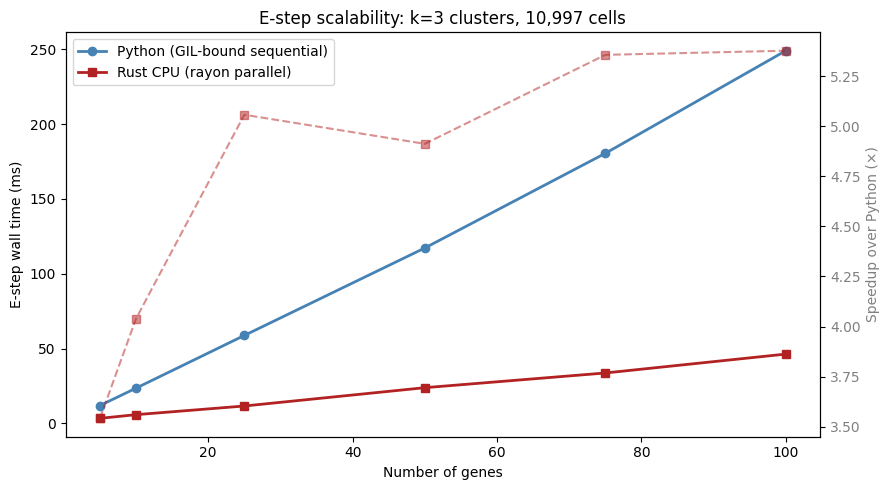

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gene_counts, py_times,   'o-', color=C_PY,   lw=2, label='Python (GIL-bound sequential)')
ax.plot(gene_counts, rust_times, 's-', color=C_RUST,  lw=2, label='Rust CPU (rayon parallel)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('E-step wall time (ms)')
ax.set_title(f'E-step scalability: k={K} clusters, {n_cells:,} cells')
ax.legend()
ax2 = ax.twinx()
sp_rust = [p/r for p, r in zip(py_times, rust_times)]
ax2.plot(gene_counts, sp_rust, 's--', color=C_RUST, alpha=0.5)
ax2.set_ylabel('Speedup over Python (×)', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/estep_scalability.png', dpi=150)
plt.show()


## Summary

| Setup | Requirement | How to enable |
|---|---|---|
| Rust CPU | `monod_core` installed | `cd monod_core && maturin build --release && pip install target/wheels/*.whl` |
| CUDA GPU | PyTorch + CUDA device (float64) | `pip install torch` on a CUDA machine |

| Fast-path | Condition | E-step speedup (100 genes, k=3) |
|---|---|---|
| Rust CPU | `_HAS_RUST=True` | ~5× over Python |
| CUDA GPU | torch + CUDA float64 device | depends on GPU |

**Path selection** (automatic):
1. CUDA available → `_eval_model_pss_gpu` (vectorised torch)
2. Rust available → `e_step_2d` (all-Rust, one call)
3. Python fallback → sequential `eval_model_pss` loop
